In [1]:
import numpy as np
import pyvista as pv
from pyau3d.files import TopFile, PartFile, ModeFile
from pyau3d.utils import PltFileUtils, NodFileUtils, AnimSmartStream, GrpFileUtils
from pyau3d.pv.loaders import GrpFileVTK
from pyau3d.pv.loader.grpfilevtk import _grp2pv
from pyau3d.pv.vtktool.pdata import polydata
import vtk
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from pyau3d.constants import Constants
# Enable interactive backend
%matplotlib widget
 

# specify group for animation file
# group = 2 corresponds to cylinder wall - could double check in .an02 file
RE = 50
GROUP = 2
ianimgrp = GROUP
 
cfd_dir = f"/home/ahf25/CFD_2d_cylinder_all/Unsteady/2d_cylinder_Re{RE}_unsteady"
nod_file = f"cylinder.nod"
plt_file = "cylinder.plt"
grp_file =f"cylinder.grp{GROUP:02}"
an_file = f"cylinder.an{GROUP:02}"
part_file = "cylinder.part"

# specify file paths

path2nod = cfd_dir + "/" + nod_file
path2plt = cfd_dir  + "/" +  plt_file
path2grp = cfd_dir  + "/" +  grp_file
path2an = cfd_dir  + "/" +  an_file
path2part = cfd_dir  + "/" +  part_file
 
mesh = PltFileUtils(path2plt)
nod = NodFileUtils(path2nod)
grp = GrpFileUtils(path2grp,GROUP)
groupfile = GrpFileVTK(path2grp,GROUP)
anim_vars = nod.ivars[GROUP - 1]
part_file = PartFile(path2part)

anim = AnimSmartStream(
    path2an,
    anim_vars=anim_vars,
    part=part_file,
    grp=grp
)
 

In [2]:

# write function to calculate area_normals
# not using polydata.area_normals since ifac4 is not available in my mesh

def area_normals(coord, ifac3):
    """
    Returns a pyvista.PolyData object with point normals scaled by the area of adjacent faces.

    Args:
        coord  : (N, 3) array of mesh point coordinates
        ifac3  : (M, 3) array of triangle connectivity (zero-based indices)

    Returns:
        pdata  : pyvista.PolyData with 'anor' field = area-weighted normals at each point
    """
    nfac3 = len(ifac3)

    # --- build PolyData from triangles ---
    faces = np.hstack([
        np.full((nfac3, 1), 3),   # each face has 3 vertices
        ifac3
    ]).flatten()

    pdata = pv.PolyData(coord, faces)

    # --- compute face areas ---
    pdata = pdata.compute_cell_sizes(length=False, volume=False)  # adds 'Area' field
    face_areas = pdata['Area']  # shape (nfac3,)

    # --- accumulate area contribution at each point ---
    # each triangle shares its area equally among its 3 vertices
    points_area = np.zeros(len(coord))
    np.add.at(points_area, ifac3, face_areas[:, np.newaxis] / 3.0)

    # --- scale point normals by accumulated area ---
    pdata['anor'] = -pdata.point_normals * points_area[:, np.newaxis]

    return pdata

In [3]:
blade = area_normals(grp.coords, grp.icon3)
# define delta t
deltat = 0.001
force = []
# start of frame = 1
# end of frame = 2000
# interval = 1
iframe = np.arange(1,2000,1)

for i in iframe:
    x = grp.coords[:,0]
    y = grp.coords[:,1]
    z = grp.coords[:,2]
 
    locp = np.searchsorted(nod.ivars[ianimgrp - 1],9)
    variables = np.arange(nod.nvars[ianimgrp - 1])
 
    data = anim.read_frame(i,variables, )#redim = True,)
 
    blade['p'] = data[:, locp] * 10000
    blade['F'] = blade['p'][:] * np.dot(blade['anor'],[0,1,0]) # compute lift force area normal * y_unit vector
 
    Force = np.sum(blade['F'], axis = 0)
    force += [Force]

force = np.array(force)
t = np.arange(1,2000,1) * deltat

In [4]:
U_inf = 34.02626486 # farfield velocity (m/s)
rho_inf = 2.10E-05 # farfield density (kg/m^3)
surface_area = 1


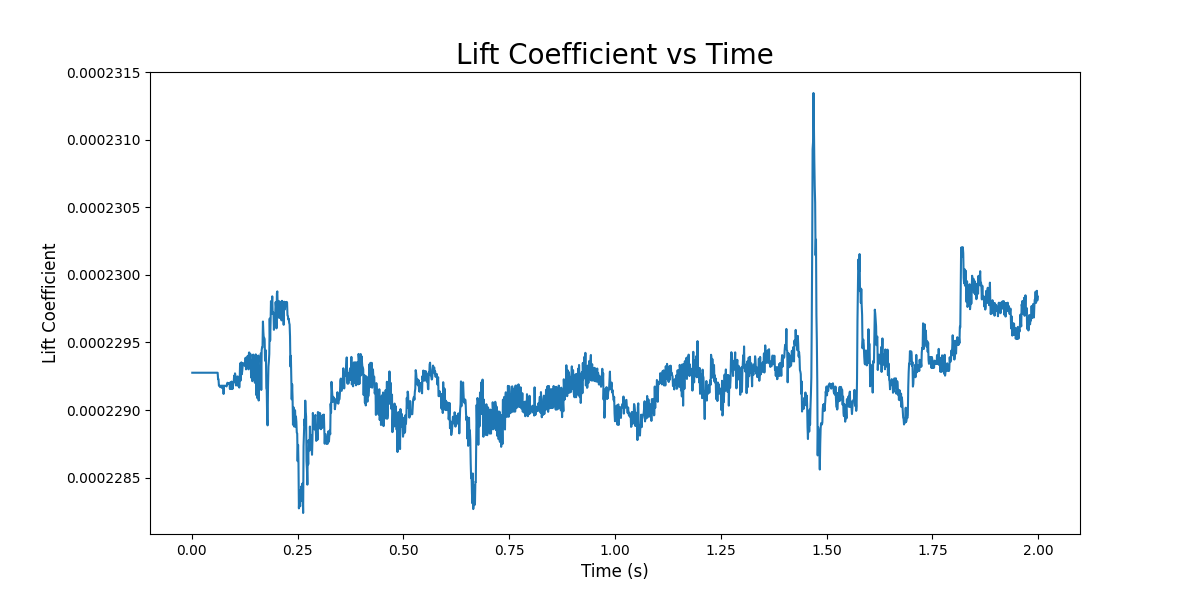

In [5]:
CL = force / (0.5 * rho_inf * U_inf **2 * surface_area)
plt.figure(figsize=(12, 6))
plt.plot(t, CL)
plt.title("Lift Coefficient vs Time", fontsize = 20)
plt.xlabel("Time (s)", fontsize = 12)
plt.ylabel("Lift Coefficient", fontsize = 12)
plt.savefig(f"../../images/Re{RE}_unsteady/Re{RE}_cl")

np.savetxt(f'../../data/Re{RE}/au3d_unsteady_Re{RE}_cl.csv', (t,CL), delimiter=',')

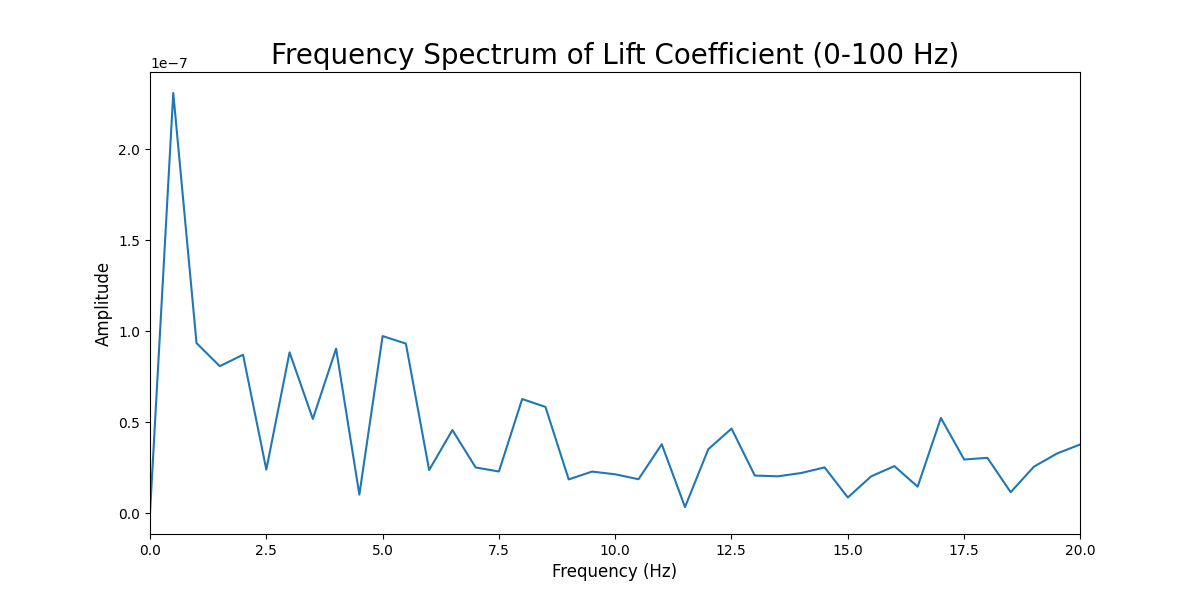

In [6]:
CL_fluctuation = CL - np.mean(CL)

N = len(CL_fluctuation)
dt = t[1] - t[0]

freqs = np.fft.rfftfreq(N, d=dt)
fft_vals = np.fft.rfft(CL_fluctuation)
amplitude = np.abs(fft_vals) * 2 / N

plt.figure(figsize=(12, 6))
plt.plot(freqs, amplitude)
plt.title("Frequency Spectrum of Lift Coefficient (0-100 Hz)", fontsize = 20)
plt.xlabel("Frequency (Hz)", fontsize = 12)
plt.ylabel("Amplitude",fontsize = 12)
plt.xlim(0,20)
plt.savefig("../../images/Re50_unsteady/Re50_cl_fft")
np.savetxt(f'../../data/Re{RE}/au3d_unsteady_Re{RE}_cl_fft.csv', (freqs, amplitude), delimiter=',')